## Project Introduction

This project develops a music **recommender system** using the Spotify Million Playlist Dataset (MPD). The goal is to address the task of **Automatic Playlist Continuation (APC)**, where a recommendation system predicts additional tracks for a partially observed playlist.

Given a playlist title and an initial set of tracks (called the **seed playlist**), the recommender system aims to generate a ranked list of tracks that are likely to appear in the remainder of the playlist.

In this project, we explore several recommendation approaches, including:

**popularity-based recommendation**

**item–item similarity models**

**collaborative filtering using matrix factorization (ALS)**

**hybrid methods incorporating playlist title information**

## Data Pipeline

This project uses the **Spotify Million Playlist Dataset (MPD)** for the task of **Automatic Playlist Continuation (APC)**. The raw dataset consists of 1,000 JSON slice files, each containing playlist metadata and track lists.

The following table summarizes the preprocessing and modeling pipeline used in this project.

| Stage              | Description                                                                                            | Output                            |
| ------------------ | ------------------------------------------------------------------------------------------------------ | --------------------------------- |
| Raw Dataset        | Spotify Million Playlist Dataset stored as JSON slice files (`mpd.slice.*.json`)                       | Playlist metadata and track lists |
| Data Parsing       | Read JSON files and extract playlist ID, playlist title, track URI, and track position                 | Structured playlist–track records |
| Track Indexing     | Map each unique `track_uri` to a numeric index (`track2idx`)                                           | Integer track IDs                 |
| Interaction Matrix | Construct a sparse playlist–track matrix where rows are playlists and columns are tracks               | Sparse matrix representation      |
| APC Split          | Split each playlist into seed tracks and ground truth continuation tracks                              | `X_seed_s*.npz` and `gt_s*.json`  |
| Model Training     | Train recommender models such as popularity baseline, item similarity, and ALS collaborative filtering | Trained recommendation models     |
| Recommendation     | Generate ranked track recommendations for each seed playlist                                           | Top-N recommended tracks          |
| Evaluation         | Compare recommendations with ground truth tracks using ranking metrics                                 | R-Precision, Recall@500, NDCG@500 |


### Step 1: Raw Dataset

The original dataset is the Spotify Million Playlist Dataset, organized as JSON files such as:

* `mpd.slice.0-999.json`
* `mpd.slice.1000-1999.json`
* ...
* `mpd.slice.999000-999999.json`

Each playlist contains:

* playlist ID (`pid`)
* playlist title (`name`)
* ordered list of tracks (`track_uri`)
* optional metadata such as track position


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from pathlib import Path
from zipfile import ZipFile

ZIP_PATH = Path("/content/drive/MyDrive/Winter/ml1/spotify_million_playlist_dataset.zip")
EXTRACT_DIR = Path("/content/mpd_2pct")
EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

with ZipFile(ZIP_PATH, "r") as z:
    json_files = sorted([n for n in z.namelist() if n.endswith(".json") and "mpd.slice." in n])
    all_files = json_files

    print("Total slice files in zip:", len(json_files))
    print("Extracting:", len(all_files), "files")

    for name in all_files:
        z.extract(name, EXTRACT_DIR)

print("Done.")

Total slice files in zip: 1000
Extracting: 1000 files
Done.


In [ ]:
from pathlib import Path

MPD_DIR = Path("/content/mpd_2pct/data")
slice_files = sorted(MPD_DIR.glob("mpd.slice.*.json"))

print("Exists:", MPD_DIR.exists())
print("Is dir:", MPD_DIR.is_dir())
print("Number of slices found:", len(slice_files))
print("First 5 slice files:")
for p in slice_files[:5]:
    print(p.name)


Exists: True
Is dir: True
Number of slices found: 1000
First 5 slice files:
mpd.slice.0-999.json
mpd.slice.1000-1999.json
mpd.slice.10000-10999.json
mpd.slice.100000-100999.json
mpd.slice.101000-101999.json


In [ ]:
slice_files = sorted(MPD_DIR.glob("mpd.slice.*.json"))

print("Number of slices:", len(slice_files))
print("First slice:", slice_files[0].name)
print("Last slice:", slice_files[-1].name)

Number of slices: 1000
First slice: mpd.slice.0-999.json
Last slice: mpd.slice.999000-999999.json


### Step 2: Data Parsing

We parse the JSON slice files and extract the fields needed for recommendation:

* playlist ID
* playlist title
* track URI
* track position

### Step 3: Track Indexing

Since machine learning models require numerical input, each unique `track_uri` is mapped to an integer index using a dictionary such as `track2idx`.

In [ ]:
import json
import numpy as np
from pathlib import Path
from scipy.sparse import coo_matrix

def iter_mpd_playlists(slice_path: Path):
    with open(slice_path, "r", encoding="utf-8") as f:
        data = json.load(f)
    yield from data["playlists"]

def build_indices(slice_files):
    track2idx = {}
    pids, titles = [], []

    def get_track_idx(uri):
        j = track2idx.get(uri)
        if j is None:
            j = len(track2idx)
            track2idx[uri] = j
        return j

    for fp in slice_files:
        for pl in iter_mpd_playlists(fp):
            pids.append(pl["pid"])
            titles.append((pl.get("name") or "").strip())
            for tr in pl["tracks"]:
                get_track_idx(tr["track_uri"])

    return track2idx, pids, titles

def make_apc_split(slice_files, track2idx, pid2pidx, seed_size):
    rows, cols, data = [], [], []
    ground_truth = {}

    for fp in slice_files:
        for pl in iter_mpd_playlists(fp):
            pidx = pid2pidx[pl["pid"]]
            tracks = pl["tracks"]

            # seed
            for tr in tracks[:seed_size]:
                tidx = track2idx[tr["track_uri"]]
                rows.append(pidx); cols.append(tidx); data.append(1.0)

            # holdout
            if len(tracks) > seed_size:
                held = tracks[seed_size:]
                ground_truth[pidx] = [track2idx[t["track_uri"]] for t in held]

    n_playlists = len(pid2pidx)
    n_tracks = len(track2idx)
    X_seed = coo_matrix((np.array(data, dtype=np.float32), (rows, cols)),
                        shape=(n_playlists, n_tracks)).tocsr()
    X_seed.eliminate_zeros()
    return X_seed, ground_truth

### Step 4: Playlist–Track Interaction Matrix

We construct a sparse matrix where:

* rows represent playlists
* columns represent tracks
* entries indicate whether a track appears in a playlist

This matrix is the main input for collaborative filtering models such as ALS.

### Step 5: Automatic Playlist Continuation Split

To simulate the recommendation task, each playlist is split into:

* **seed tracks**: the observed first few tracks
* **ground truth tracks**: the remaining tracks to predict

For example, if the seed size is 5, the model sees the first 5 tracks and tries to recommend the rest.

In [ ]:
TEST_SLICES = slice_files[:10] # modify for smaller sample size
track2idx, pids, titles = build_indices(TEST_SLICES)
pid2pidx = {pid: i for i, pid in enumerate(pids)}
X_seed_5, gt_5 = make_apc_split(TEST_SLICES, track2idx, pid2pidx, seed_size=5)

print("Playlists:", len(pids))
print("Tracks:", len(track2idx))
print("X_seed_5:", X_seed_5.shape, "nnz:", X_seed_5.nnz)
print("GT playlists:", len(gt_5))

Playlists: 10000
Tracks: 169657
X_seed_5: (10000, 169657) nnz: 49935
GT playlists: 9936


In [ ]:
import os, json
from pathlib import Path
from scipy.sparse import save_npz

ART_DIR = Path("./artifacts_mpd")
ART_DIR.mkdir(parents=True, exist_ok=True)

def save_json(obj, path):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f)

# Save indices / metadata
save_json(track2idx, ART_DIR / "track2idx.json")
save_json(pids, ART_DIR / "pids.json")
save_json(titles, ART_DIR / "titles.json")

seed_sizes = [1, 5, 10, 25]
splits = {}

for s in seed_sizes:
    X_seed, gt = make_apc_split(TEST_SLICES, track2idx, pid2pidx, seed_size=s)
    save_npz(ART_DIR / f"X_seed_s{s}.npz", X_seed)
    # JSON keys must be strings
    save_json({str(k): v for k, v in gt.items()}, ART_DIR / f"gt_s{s}.json")
    print(f"saved seed {s}: X nnz={X_seed.nnz:,} | gt playlists={len(gt):,}")

saved seed 1: X nnz=10,000 | gt playlists=10,000
saved seed 5: X nnz=49,935 | gt playlists=9,936
saved seed 10: X nnz=98,758 | gt playlists=9,539
saved seed 25: X nnz=227,184 | gt playlists=7,533


In [ ]:
import numpy as np
import pandas as pd
import random

def r_precision(rec, gt):
    R = len(gt)
    if R == 0: return 0.0
    return len(set(rec[:R]) & set(gt)) / R

def recall_at_k(rec, gt, k=500):
    if len(gt) == 0: return 0.0
    return len(set(rec[:k]) & set(gt)) / len(gt)

def ndcg_at_k(rec, gt, k=500):
    if len(gt) == 0: return 0.0
    gt_set = set(gt)
    dcg = 0.0
    for rank, item in enumerate(rec[:k], start=1):
        if item in gt_set:
            dcg += 1.0 / np.log2(rank + 1)
    ideal = min(len(gt), k)
    idcg = sum(1.0 / np.log2(r + 1) for r in range(1, ideal + 1))
    return dcg / idcg if idcg > 0 else 0.0

def evaluate_recommender(recommender_fn, gt_dict, sample_size=2000, K=500, seed_size=None, random_state=0):
    rng = random.Random(random_state)
    keys = list(gt_dict.keys())
    if len(keys) == 0:
        raise ValueError("Empty ground truth.")
    sample = keys if len(keys) <= sample_size else rng.sample(keys, sample_size)

    rows = []
    for pidx in sample:
        gt = gt_dict[pidx]
        rec = recommender_fn(pidx, K)
        rows.append({
            "seed_size": seed_size,
            "r_precision": r_precision(rec, gt),
            "recall@500": recall_at_k(rec, gt, k=K),
            "ndcg@500": ndcg_at_k(rec, gt, k=K),
        })
    df = pd.DataFrame(rows)
    return df, df.mean(numeric_only=True).to_dict()


### Step 6: Model Training

The processed interaction matrix is used to train recommender models, including:

* popularity baseline
* item-item similarity
* ALS matrix factorization

### Step 7: Recommendation and Evaluation

For each seed playlist, the model generates a ranked list of candidate tracks. Recommendations are evaluated against the withheld ground truth using:

* **R-Precision**
* **Recall@500**
* **NDCG@500**


## Baseline Models

Before training more advanced recommender systems, we implement baseline models to establish reference performance. A baseline is important because it provides a simple benchmark against which more sophisticated approaches, such as matrix factorization, can be compared.

In this project, we use two baseline recommenders:

### 1. Popularity-Based Recommender

The popularity model recommends tracks that appear most frequently across playlists in the training data. This approach does not personalize recommendations beyond excluding tracks that already appear in the seed playlist.

Its main advantage is simplicity and efficiency. Although it ignores playlist-specific structure, it often provides a strong benchmark, especially for common or broadly popular tracks.


In [ ]:
# Global popularity from training seed matrix
popularity_scores = np.asarray(X_seed.sum(axis=0)).ravel()
popularity_ranking = np.argsort(-popularity_scores)

def popularity_recommender(pidx, K=500):
    seen_tracks = set(X_seed[pidx].indices)
    recs = []
    for tidx in popularity_ranking:
        if tidx not in seen_tracks:
            recs.append(int(tidx))
        if len(recs) >= K:
            break
    return recs

example_pidx = next(iter(gt.keys()))
print(popularity_recommender(example_pidx, K=10))

[3713, 1396, 1874, 1335, 4214, 1581, 1925, 2701, 3545, 1668]


In [ ]:
idx2track = {v: k for k, v in track2idx.items()}
[idx2track[i] for i in popularity_recommender(example_pidx, K=10)]

['spotify:track:1xznGGDReH1oQq0xzbwXa3',
 'spotify:track:7yyRTcZmCiyzzJlNzGC9Ol',
 'spotify:track:7BKLCZ1jbUBVqRi2FVlTVw',
 'spotify:track:7KXjTSCq5nL1LoYtL7XAwS',
 'spotify:track:62vpWI1CHwFy7tMIcSStl8',
 'spotify:track:6O6M7pJLABmfBRoGZMu76Y',
 'spotify:track:27GmP9AWRs744SzKcpJsTZ',
 'spotify:track:5hTpBe8h35rJ67eAWHQsJx',
 'spotify:track:152lZdxL1OR0ZMW6KquMif',
 'spotify:track:7yq4Qj7cqayVTp3FF9CWbm']

In [ ]:
def spotify_link(uri):
    return uri.replace("spotify:track:", "https://open.spotify.com/track/")

In [ ]:
track_metadata = {}

for fp in TEST_SLICES:   # or slice_files if you want the full dataset
    for pl in iter_mpd_playlists(fp):
        for tr in pl["tracks"]:
            uri = tr["track_uri"]
            tidx = track2idx.get(uri)

            if tidx is not None and tidx not in track_metadata:
                track_metadata[tidx] = {
                    "track_uri": tr["track_uri"],
                    "track_name": tr.get("track_name", ""),
                    "artist_name": tr.get("artist_name", "")
                }

In [ ]:
def show_recommendations(rec_list):
    rows = []

    for tidx in rec_list:
        meta = track_metadata.get(tidx, {})
        rows.append({
            "track_name": meta.get("track_name"),
            "artist_name": meta.get("artist_name"),
            "spotify_link": spotify_link(meta.get("track_uri",""))
        })

    return pd.DataFrame(rows)

In [ ]:
rec = popularity_recommender(example_pidx, K=10)
show_recommendations(rec)

,track_name,artist_name,spotify_link
0,One Dance,Drake,https://open.spotify.com/track/1xznGGDReH1oQq0...
1,Broccoli (feat. Lil Yachty),DRAM,https://open.spotify.com/track/7yyRTcZmCiyzzJl...
2,Closer,The Chainsmokers,https://open.spotify.com/track/7BKLCZ1jbUBVqRi...
3,HUMBLE.,Kendrick Lamar,https://open.spotify.com/track/7KXjTSCq5nL1LoY...
4,No Role Modelz,J. Cole,https://open.spotify.com/track/62vpWI1CHwFy7tM...
5,Roses,The Chainsmokers,https://open.spotify.com/track/6O6M7pJLABmfBRo...
6,Jumpman,Drake,https://open.spotify.com/track/27GmP9AWRs744Sz...
7,Caroline,Aminé,https://open.spotify.com/track/5hTpBe8h35rJ67e...
8,Location,Khalid,https://open.spotify.com/track/152lZdxL1OR0ZMW...
9,Riptide,Vance Joy,https://open.spotify.com/track/7yq4Qj7cqayVTp3...


In [ ]:
pop_df, pop_summary = evaluate_recommender(popularity_recommender, gt, sample_size=1000, K=500)
pop_summary

{'r_precision': 0.0203461925209432,
 'recall@500': 0.11396128818053589,
 'ndcg@500': 0.06510474731134738}

### 2. Item-Item Similarity Recommender

The item-item similarity model recommends tracks that tend to co-occur with the seed tracks in playlists. The idea is that if two tracks often appear together, then one track may be a good recommendation when the other is already present in the playlist.

This baseline is more personalized than the popularity model because recommendations depend on the specific seed tracks in the playlist.

In [ ]:
from sklearn.preprocessing import normalize
import numpy as np

# X_seed: playlists x tracks
# convert to track x playlists
item_matrix = X_seed.T.tocsr()

# L2-normalize each track vector so cosine similarity becomes dot product
item_matrix_norm = normalize(item_matrix, norm="l2", axis=1)

In [ ]:
def item_similarity_recommender(pidx, K=500):
    seed_items = X_seed[pidx].indices
    seen_tracks = set(seed_items)

    if len(seed_items) == 0:
        return popularity_recommender(pidx, K)

    seed_vecs = item_matrix_norm[seed_items]   # shape: (#seed, #playlists)

    sim_scores = seed_vecs @ item_matrix_norm.T   # shape: (#seed, #tracks)
    sim_scores = np.asarray(sim_scores.sum(axis=0)).ravel()

    if len(seen_tracks) > 0:
        sim_scores[list(seen_tracks)] = -np.inf

    K_eff = min(K, len(sim_scores))
    top_idx = np.argpartition(-sim_scores, K_eff - 1)[:K_eff]
    top_idx = top_idx[np.argsort(-sim_scores[top_idx])]

    return [int(i) for i in top_idx]

In [ ]:
item_rec = item_similarity_recommender(example_pidx, K=10)
print(item_rec)
show_recommendations(item_rec)

[1979, 5559, 2474, 1980, 15357, 11880, 1991, 12059, 12063, 5558]


,track_name,artist_name,spotify_link
0,"One, Two Step",Ciara,https://open.spotify.com/track/7uKcScNXuO3MWw6...
1,My Humps,The Black Eyed Peas,https://open.spotify.com/track/2WNVqZq1ujhMDlO...
2,Hollaback Girl,Gwen Stefani,https://open.spotify.com/track/6RcQOut9fWL6FSq...
3,Ignition - Remix,R. Kelly,https://open.spotify.com/track/5dNfHmqgr128gMY...
4,Milkshake,Kelis,https://open.spotify.com/track/2cMTIlktg3M9mXY...
5,Fergalicious,Fergie,https://open.spotify.com/track/1D066zixBwqFYqB...
6,Umbrella,Rihanna,https://open.spotify.com/track/5i66xrvSh1MjjyD...
7,Don't Cha,Busta Rhymes,https://open.spotify.com/track/0vupCkmy497h49a...
8,When I Grow Up,The Pussycat Dolls,https://open.spotify.com/track/0dQQWHlXvuw4UyH...
9,Hot In Herre,Nelly,https://open.spotify.com/track/04KTF78FFg8sOHC...


In [ ]:
item_df, item_summary = evaluate_recommender(
    item_similarity_recommender,
    gt,
    sample_size=1000,
    K=500
)

item_summary

{'r_precision': 0.07272169003356259,
 'recall@500': 0.2801086241926242,
 'ndcg@500': 0.17457397622028717}

In [ ]:
comparison = pd.DataFrame([
    {
        "Model": "Popularity",
        "R-Precision": pop_summary["r_precision"],
        "Recall@500": pop_summary["recall@500"],
        "NDCG@500": pop_summary["ndcg@500"],
    },
    {
        "Model": "Item-Item Similarity",
        "R-Precision": item_summary["r_precision"],
        "Recall@500": item_summary["recall@500"],
        "NDCG@500": item_summary["ndcg@500"],
    }
])

comparison

,Model,R-Precision,Recall@500,NDCG@500
0,Popularity,0.020346,0.113961,0.065105
1,Item-Item Similarity,0.072722,0.280109,0.174574


## ALS Collaborative Filtering

To move beyond simple baseline recommenders, we implement a collaborative filtering model using Alternating Least Squares (ALS). ALS is a matrix factorization method designed for large sparse implicit-feedback datasets, which makes it well suited for playlist recommendation.

In this setting, the playlist–track interaction matrix is factorized into two low-dimensional matrices: one representing latent playlist factors and one representing latent track factors. These latent factors capture hidden structure in the data, such as groups of tracks that frequently appear together and playlists with similar musical patterns.

For a given playlist and candidate track, ALS estimates a relevance score based on the dot product of their latent vectors. Tracks with higher scores are ranked higher in the recommendation list.

Compared with popularity and item-item similarity baselines, ALS can model more complex relationships because it learns shared latent representations across all playlists and tracks in the dataset.

In this project, we use the implicit library to train ALS on the sparse playlist–track interaction matrix and evaluate its performance using the same APC setup and ranking metrics as the baseline models.

In [ ]:
import implicit
import numpy as np

alpha = 40

user_items = (X_seed * alpha).tocsr()

print("user_items shape:", user_items.shape)

als_model = implicit.als.AlternatingLeastSquares(
    factors=128,
    regularization=0.05,
    iterations=20,
    random_state=42
)

als_model.fit(user_items)

user_items shape: (10000, 169657)


  0%|          | 0/20 [00:00<?, ?it/s]

In [ ]:
def als_recommender(pidx, K=500):
    pidx = int(pidx)

    # playlist latent vector
    user_vec = als_model.user_factors[pidx]

    # score all tracks
    scores = als_model.item_factors @ user_vec

    # exclude already seen tracks
    seen = X_seed[pidx].indices
    scores[seen] = -np.inf

    K_eff = min(K, len(scores))
    top_idx = np.argpartition(-scores, K_eff - 1)[:K_eff]
    top_idx = top_idx[np.argsort(-scores[top_idx])]

    return [int(i) for i in top_idx]

In [ ]:
als_rec = als_recommender(example_pidx, K=10)
print(als_rec)
show_recommendations(als_rec)

[1979, 2474, 1980, 1991, 12059, 6409, 5557, 5559, 12063, 15357]


,track_name,artist_name,spotify_link
0,"One, Two Step",Ciara,https://open.spotify.com/track/7uKcScNXuO3MWw6...
1,Hollaback Girl,Gwen Stefani,https://open.spotify.com/track/6RcQOut9fWL6FSq...
2,Ignition - Remix,R. Kelly,https://open.spotify.com/track/5dNfHmqgr128gMY...
3,Umbrella,Rihanna,https://open.spotify.com/track/5i66xrvSh1MjjyD...
4,Don't Cha,Busta Rhymes,https://open.spotify.com/track/0vupCkmy497h49a...
5,Pon de Replay,Rihanna,https://open.spotify.com/track/3U3Ff8ZvL6oEu1r...
6,Hips Don't Lie,Shakira,https://open.spotify.com/track/3ZFTkvIE7kyPt6N...
7,My Humps,The Black Eyed Peas,https://open.spotify.com/track/2WNVqZq1ujhMDlO...
8,When I Grow Up,The Pussycat Dolls,https://open.spotify.com/track/0dQQWHlXvuw4UyH...
9,Milkshake,Kelis,https://open.spotify.com/track/2cMTIlktg3M9mXY...


In [ ]:
als_df, als_summary = evaluate_recommender(
    als_recommender,
    gt,
    sample_size=500,
    K=500
)

als_summary

{'r_precision': 0.10549409471541032,
 'recall@500': 0.345622641854579,
 'ndcg@500': 0.22981799993104596}

## Final Model Comparison

The following table compares the performance of the baseline recommenders and the ALS collaborative filtering model using the same evaluation metrics. A bar chart is also included to visualize differences in recommendation quality across models.

In [ ]:
import pandas as pd

comparison = pd.DataFrame([
    {
        "Model": "Popularity",
        "R-Precision": pop_summary["r_precision"],
        "Recall@500": pop_summary["recall@500"],
        "NDCG@500": pop_summary["ndcg@500"],
    },
    {
        "Model": "Item-Item Similarity",
        "R-Precision": item_summary["r_precision"],
        "Recall@500": item_summary["recall@500"],
        "NDCG@500": item_summary["ndcg@500"],
    },
    {
        "Model": "ALS",
        "R-Precision": als_summary["r_precision"],
        "Recall@500": als_summary["recall@500"],
        "NDCG@500": als_summary["ndcg@500"],
    }
])

comparison = comparison.round(4)
comparison

,Model,R-Precision,Recall@500,NDCG@500
0,Popularity,0.0203,0.1140,0.0651
1,Item-Item Similarity,0.0727,0.2801,0.1746
2,ALS,0.1055,0.3456,0.2298


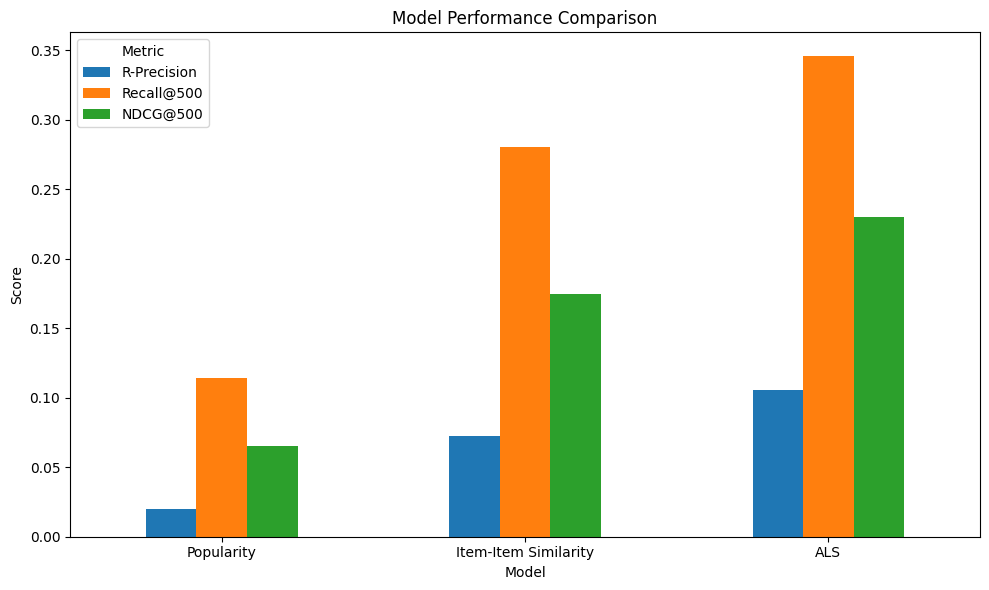

In [ ]:
import matplotlib.pyplot as plt

comparison_plot = comparison.set_index("Model")

ax = comparison_plot.plot(kind="bar", figsize=(10, 6))

plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

## Hybrid Recommendation Model

To further improve recommendation quality, we implement a hybrid recommender that combines collaborative filtering with playlist title information.

The ALS model captures latent relationships between playlists and tracks based on interaction patterns, but it does not directly use playlist titles. However, playlist titles often contain useful semantic information such as genre, mood, or activity (for example, workout, chill, or party).

To incorporate this information, we build a title-based similarity model using TF-IDF representations of playlist titles. For a target playlist, we first identify playlists with similar titles, then aggregate tracks from those playlists to form a title-based recommendation score.

The final hybrid score is computed as a weighted combination of the ALS score and the title-based score:

#### $\text{Hybrid Score} = \alpha \cdot \text{ALS Score} + (1 - \alpha) \cdot \text{Title Score}$

where $\alpha$ controls the relative contribution of collaborative filtering and title similarity.

This approach combines latent interaction patterns with content-based information from playlist titles.

In [ ]:
import json
from pathlib import Path

ART_DIR = Path("./artifacts_mpd")

with open(ART_DIR / "titles.json", "r", encoding="utf-8") as f:
    titles = json.load(f)

print(len(titles), "playlist titles loaded")

10000 playlist titles loaded


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words="english")
title_matrix = tfidf.fit_transform(titles)

print(title_matrix.shape)

(10000, 2725)


In [ ]:
def title_score_vector(pidx, top_n_neighbors=50):
    # similarity between this playlist title and all playlist titles
    sim = cosine_similarity(title_matrix[pidx], title_matrix).ravel()

    # exclude itself
    sim[pidx] = 0.0

    # get top similar playlists
    n = min(top_n_neighbors, len(sim))
    nbr_idx = np.argpartition(-sim, n - 1)[:n]
    nbr_idx = nbr_idx[np.argsort(-sim[nbr_idx])]

    # weighted sum of neighbor playlist rows
    neighbor_weights = sim[nbr_idx]
    weighted_tracks = X_seed[nbr_idx].multiply(neighbor_weights[:, None])

    # title-based track scores
    scores = np.asarray(weighted_tracks.sum(axis=0)).ravel()
    return scores

In [ ]:
def als_score_vector(pidx):
    user_vec = als_model.user_factors[pidx]
    scores = als_model.item_factors @ user_vec
    return np.asarray(scores).ravel()

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
def hybrid_recommender(pidx, K=500, alpha=0.8, top_n_neighbors=50):
    pidx = int(pidx)

    als_scores = als_score_vector(pidx)
    title_scores = title_score_vector(pidx, top_n_neighbors=top_n_neighbors)

    # normalize both score vectors to comparable scale
    if np.max(als_scores) > np.min(als_scores):
        als_scores = (als_scores - np.min(als_scores)) / (np.max(als_scores) - np.min(als_scores))
    else:
        als_scores = np.zeros_like(als_scores)

    if np.max(title_scores) > np.min(title_scores):
        title_scores = (title_scores - np.min(title_scores)) / (np.max(title_scores) - np.min(title_scores))
    else:
        title_scores = np.zeros_like(title_scores)

    hybrid_scores = alpha * als_scores + (1 - alpha) * title_scores

    # exclude already seen seed tracks
    seen = X_seed[pidx].indices
    hybrid_scores[seen] = -np.inf

    K_eff = min(K, len(hybrid_scores))
    top_idx = np.argpartition(-hybrid_scores, K_eff - 1)[:K_eff]
    top_idx = top_idx[np.argsort(-hybrid_scores[top_idx])]

    return [int(i) for i in top_idx]

In [ ]:
hybrid_rec = hybrid_recommender(example_pidx, K=10, alpha=0.8)
show_recommendations(hybrid_rec)

,track_name,artist_name,spotify_link
0,Ignition - Remix,R. Kelly,https://open.spotify.com/track/5dNfHmqgr128gMY...
1,Hollaback Girl,Gwen Stefani,https://open.spotify.com/track/6RcQOut9fWL6FSq...
2,"One, Two Step",Ciara,https://open.spotify.com/track/7uKcScNXuO3MWw6...
3,Buy U a Drank (Shawty Snappin'),T-Pain,https://open.spotify.com/track/4gFXY5yvHayGckJ...
4,Umbrella,Rihanna,https://open.spotify.com/track/5i66xrvSh1MjjyD...
5,Fergalicious,Fergie,https://open.spotify.com/track/1D066zixBwqFYqB...
6,Hips Don't Lie,Shakira,https://open.spotify.com/track/3ZFTkvIE7kyPt6N...
7,Don't Cha,Busta Rhymes,https://open.spotify.com/track/0vupCkmy497h49a...
8,Glamorous,Fergie,https://open.spotify.com/track/4KTtYhxFtFL7mBw...
9,My Humps,The Black Eyed Peas,https://open.spotify.com/track/2WNVqZq1ujhMDlO...


In [ ]:
hybrid_df, hybrid_summary = evaluate_recommender(
    lambda pidx, K: hybrid_recommender(pidx, K=K, alpha=0.8, top_n_neighbors=50),
    gt,
    sample_size=1000,
    K=500
)

hybrid_summary

{'r_precision': 0.10368334398515347,
 'recall@500': 0.34951405793187096,
 'ndcg@500': 0.23004837615361617}

In [ ]:
comparison = pd.DataFrame([
    {
        "Model": "Popularity",
        "R-Precision": pop_summary["r_precision"],
        "Recall@500": pop_summary["recall@500"],
        "NDCG@500": pop_summary["ndcg@500"],
    },
    {
        "Model": "Item-Item Similarity",
        "R-Precision": item_summary["r_precision"],
        "Recall@500": item_summary["recall@500"],
        "NDCG@500": item_summary["ndcg@500"],
    },
    {
        "Model": "ALS",
        "R-Precision": als_summary["r_precision"],
        "Recall@500": als_summary["recall@500"],
        "NDCG@500": als_summary["ndcg@500"],
    },
    {
        "Model": "Hybrid",
        "R-Precision": hybrid_summary["r_precision"],
        "Recall@500": hybrid_summary["recall@500"],
        "NDCG@500": hybrid_summary["ndcg@500"],
    }
]).round(4)

comparison

,Model,R-Precision,Recall@500,NDCG@500
0,Popularity,0.0203,0.1140,0.0651
1,Item-Item Similarity,0.0727,0.2801,0.1746
2,ALS,0.1055,0.3456,0.2298
3,Hybrid,0.1037,0.3495,0.2300


## Results Discussion

The comparison shows a clear performance improvement from simple baseline models to collaborative filtering approaches.

The popularity-based recommender performs the worst because it only recommends globally frequent tracks without considering the context of the seed playlist.

The item-item similarity model significantly improves recommendation quality by leveraging co-occurrence patterns between tracks across playlists. This allows the model to recommend tracks that commonly appear together.

The ALS model achieves the best performance across all evaluation metrics. By factorizing the playlist–track interaction matrix, ALS learns latent representations that capture deeper relationships between playlists and tracks. These latent factors allow the model to identify hidden structures such as genre clusters, mood similarities, and playlist composition patterns.

Overall, the results demonstrate that collaborative filtering provides a more expressive and effective approach for automatic playlist continuation than simple popularity or similarity-based baselines.

# Model Demo

In [ ]:
track_metadata_str_keys = {str(k): v for k, v in track_metadata.items()}

with open(ART_DIR / "track_metadata.json", "w", encoding="utf-8") as f:
    json.dump(track_metadata_str_keys, f)

print("Saved track_metadata.json successfully!")

Saved track_metadata.json successfully!


In [ ]:
# Save trained model to the artifacts folder
als_model.save(ART_DIR / "als_model.npz")
print("Model saved successfully!")

Model saved successfully!


In [ ]:
%%writefile app_demo.py

import os
os.environ['OPENBLAS_NUM_THREADS'] = '1'

import streamlit as st
import json
import numpy as np
import scipy.sparse as sp
import implicit

# Need to first save track metadata and trained ALS model to artifacts folder
# Add this after the cell that generates track metadata list:
# track_metadata_str_keys = {str(k): v for k, v in track_metadata.items()}

# with open(ART_DIR / "track_metadata.json", "w", encoding="utf-8") as f:
#     json.dump(track_metadata_str_keys, f)

# print("Saved track_metadata.json successfully!")

# Add this after the cell that trains ALS model:
# als_model.save(ART_DIR / "als_model.npz")
# print("Model saved successfully!")

# 1. Setup Paths & Load Data Safely
BASE_DIR = os.path.dirname(os.path.abspath(__file__))
ART_DIR = os.path.join(BASE_DIR, 'artifacts_mpd')

@st.cache_resource
def load_data():
    with open(os.path.join(ART_DIR, 'track_metadata.json'), 'r', encoding="utf-8") as f:
        track_metadata = json.load(f)
    with open(os.path.join(ART_DIR, 'track2idx.json'), 'r', encoding="utf-8") as f:
        track2idx = json.load(f)

    model_path = os.path.join(ART_DIR, 'als_model.npz')
    if os.path.exists(model_path):
        model = implicit.cpu.als.AlternatingLeastSquares.load(model_path)
    else:
        model = None

    return track_metadata, track2idx, model

track_metadata, track2idx, model = load_data()

# 2. Setup "Memory" for the app (Session State)
if 'seed_playlist' not in st.session_state:
    st.session_state.seed_playlist = []

# --- BUILD THE USER INTERFACE ---
st.title("🎵 AI Playlist Continuer")

if model is None:
    st.error("⚠️ Model not found! Please check your file paths.")
    st.stop()

# --- Section 1: The Playlist Builder ---
st.subheader("🎧 Your Seed Playlist")

if not st.session_state.seed_playlist:
    st.info("Your playlist is empty! Search below to add some tracks.")
else:
    for i, track in enumerate(st.session_state.seed_playlist):
        st.write(f"**{i+1}.** {track['name']} by {track['artist']}")

    if st.button("🗑️ Clear Playlist"):
        st.session_state.seed_playlist = []
        st.rerun()

st.divider()

# --- Section 2: The Search Bar ---
search_query = st.text_input("Search for a song to add to your playlist:")

if search_query:
    matches = []
    for idx, data in track_metadata.items():
        if search_query.lower() in data['track_name'].lower():
            matches.append((idx, data['track_name'], data['artist_name'], data['track_uri']))
            if len(matches) >= 5:
                break

    if not matches:
        st.warning("No songs found.")
    else:
        st.write("*Click to add a track:*")
        for idx, track_name, artist, uri in matches:
            if st.button(f"➕ {track_name} by {artist}", key=f"search_{idx}"):
                st.session_state.seed_playlist.append({
                    'name': track_name,
                    'artist': artist,
                    'math_index': track2idx[uri]
                })
                # Clear the search bar text visually by rerunning
                st.rerun()

st.divider()

# --- Section 3: The AUTO-GENERATING AI Recommendations ---
# If they have at least 1 track, we instantly show recommendations!
if len(st.session_state.seed_playlist) > 0:
    st.subheader("🔥 AI Recommendations")
    st.write("Click ➕ to add a recommended song to your playlist. The AI will instantly adapt to your new vibe!")

    # 1. Get all math indices from the session state
    seed_indices = [track['math_index'] for track in st.session_state.seed_playlist]

    # 2. Build the Matrix Row for this user
    num_total_tracks = len(track2idx)
    data = [1.0] * len(seed_indices)
    rows = [0] * len(seed_indices)
    user_items = sp.csr_matrix((data, (rows, seed_indices)), shape=(1, num_total_tracks))

    # 3. Ask the model for recommendations (ask for extra in case of duplicates)
    ids, scores = model.recommend(0, user_items[0], N=20, recalculate_user=True)

    # 4. Display results with Add Buttons!
    rank = 1
    for recommended_idx in ids:
        rec_idx_int = int(recommended_idx) # Ensure it's a clean integer

        # Don't recommend songs already in the seed playlist
        if rec_idx_int not in seed_indices:
            rec_data = track_metadata[str(rec_idx_int)]

            # Use columns to make it look like a real app (Text on left, Button on right)
            col1, col2 = st.columns([4, 1])

            with col1:
                st.write(f"**{rank}.** {rec_data['track_name']} by {rec_data['artist_name']}")

            with col2:
                # Add a unique key to the button so Streamlit doesn't get confused
                if st.button("➕ Add", key=f"rec_{rec_idx_int}"):
                    st.session_state.seed_playlist.append({
                        'name': rec_data['track_name'],
                        'artist': rec_data['artist_name'],
                        'math_index': rec_idx_int
                    })
                    # Rerun instantly recalculates the math with the new song included!
                    st.rerun()

            rank += 1
            if rank > 10:
                break

Overwriting app_demo.py


In [ ]:
from google.colab import files
!zip -r artifacts_mpd.zip artifacts_mpd
files.download("artifacts_mpd.zip")

updating: artifacts_mpd/ (stored 0%)
updating: artifacts_mpd/als_model.npz (deflated 56%)
updating: artifacts_mpd/X_seed_s5.npz (deflated 7%)
updating: artifacts_mpd/titles.json (deflated 66%)
updating: artifacts_mpd/X_seed_s25.npz (deflated 4%)
updating: artifacts_mpd/track_metadata.json (deflated 69%)
updating: artifacts_mpd/gt_s10.json (deflated 62%)
updating: artifacts_mpd/X_seed_s10.npz (deflated 4%)
updating: artifacts_mpd/gt_s5.json (deflated 62%)
updating: artifacts_mpd/track2idx.json (deflated 57%)
updating: artifacts_mpd/pids.json (deflated 68%)
updating: artifacts_mpd/X_seed_s1.npz (deflated 27%)
updating: artifacts_mpd/gt_s1.json (deflated 62%)
updating: artifacts_mpd/gt_s25.json (deflated 62%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!ls -lh artifacts_mpd

total 133M
-rw-r--r-- 1 root root  88M Mar 17 09:36 als_model.npz
-rw-r--r-- 1 root root 3.8M Mar 17 09:35 gt_s10.json
-rw-r--r-- 1 root root 4.3M Mar 17 09:34 gt_s1.json
-rw-r--r-- 1 root root 2.9M Mar 17 09:35 gt_s25.json
-rw-r--r-- 1 root root 4.1M Mar 17 09:34 gt_s5.json
-rw-r--r-- 1 root root  73K Mar 17 09:34 pids.json
-rw-r--r-- 1 root root 119K Mar 17 09:34 titles.json
-rw-r--r-- 1 root root 7.7M Mar 17 09:34 track2idx.json
-rw-r--r-- 1 root root  22M Mar 17 09:36 track_metadata.json
-rw-r--r-- 1 root root 244K Mar 17 09:35 X_seed_s10.npz
-rw-r--r-- 1 root root  40K Mar 17 09:34 X_seed_s1.npz
-rw-r--r-- 1 root root 526K Mar 17 09:35 X_seed_s25.npz
-rw-r--r-- 1 root root 133K Mar 17 09:34 X_seed_s5.npz


In [ ]:
files.download("app_demo.py")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>